In [1]:
import pandas as pd
df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [5]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [6]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [7]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [8]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [9]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [10]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

In [11]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [12]:
dff = dff.sample(frac=1, random_state=42)

In [13]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

In [14]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [15]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)
# full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [16]:
from deep_learning_models import UNetThenNN

In [17]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [18]:
# model = ResNetMini()   
# model = BayesianResNetMini()
# model = UNetThenResNet()
# model = UNet()
model = UNetBayesian()
# model = UNetThenNN()
# model = ResNetHoliSmokesBayesian()
# model = ResNetHoliSmokes()

In [19]:
model.model_name

'UNetBayesian'

In [20]:
vv = viewer(model)
vv.show_model()

In [21]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,629,838
Trainable parameters: 4,629,838


In [22]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau


patience = 25
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)

best_val_loss = float('inf')
best_weights = None

In [24]:
# mettre poids plus important sur le shear que sur le Rayon d'einstein pour mieux le retrouver
# mettre incertidues sur le transformer 
def gaussian_nll(mu, log_var, y, beta=0.005):
    log_var = torch.clamp(log_var, -10, 10)
    precision = torch.exp(-log_var)
    nll = 0.5 * (precision * (y - mu)**2 + log_var)
    # Pénalise les log_var trop extrêmes
    reg = beta * (log_var ** 2).mean()
    return nll.mean() + reg

In [25]:
# import time 
# import copy
# import torch

# # N_MC = 1000  # number of MC samples for epistemic uncertainty at val time
# model.to(device)
# start = time.time()

# for epoch in range(100):
#     # ---- TRAIN ----
#     # single forward pass per batch, dropout active via training=True hardcoded in forward()
#     model.train()
#     epoch_loss = 0.0
#     for xb, yb in train_loader:
#         xb, xout = xb[0].to(device), xb[1].to(device)
#         yb, paths = yb[0].to(device), yb[1]
#         optimizer.zero_grad()
#         out_lens = model.forward_unet(xb)
# #                 out_lens = torch.cat([out_lens, xb - out_lens], dim=1)
#         mu, log_var = model.forward_resnet(out_lens)
#         # mu, log_var = model(xb)                    # aleatoric: mu + log_var predicted by network
#         loss = gaussian_nll(mu, log_var, yb)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#     train_losses.append(epoch_loss / len(train_loader))

#     print(f"log_var mean: {log_var.mean():.3f}, std: {log_var.std():.3f}")
#     # print(f"mu residuals std: {(mu - y).std():.4f}")

#    # ---- VALIDATION ----
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, xout = xb[0].to(device), xb[1].to(device)
#             yb, paths = yb[0].to(device), yb[1]
#             out_lens = model.forward_unet(xb)
#             mu, log_var = model.forward_resnet(out_lens)
            
#             # mu, log_var = model(xb)
#             loss = gaussian_nll(mu, log_var, yb)
#             val_loss += loss.item()
#     val_losses.append(val_loss / len(val_loader))
#     scheduler.step()

#     # ---- EARLY STOPPING ----
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         best_weights = copy.deepcopy(model.state_dict())
#         early_stop_counter = 0
#     else:
#         early_stop_counter += 1
#     print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
#     if early_stop_counter >= patience:
#         print(f"Early stopping triggered at epoch {epoch+1}")
#         break
# process_time = time.time() - start

In [26]:
# import os
# import torch

# os.chdir("/home/mbatt/gravitational_lensing/")

# checkpoint = {
#     "model_state_dict": best_weights,   # your best Bayesian model weights
#     "optimizer_state_dict": optimizer.state_dict(),
#     "epoch": epoch,
#     "train_losses": train_losses,
#     "val_losses": val_losses,
#     "process_time": process_time
# }
# torch.save(checkpoint, "resnet_unet_bayesian_1.pth")

In [27]:
# for name, p in model.named_parameters():
#     if 'logvar' in name and p.grad is not None:
#         print(f"{name} grad norm: {p.grad.norm():.6f}")

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-5)

# checkpoint = torch.load("resnet_bayesian_9.pth", map_location=device)
# checkpoint = torch.load("ResNetHoliSmokes_20.pth", map_location=device)
checkpoint = torch.load("resnet_unet_bayesian_1.pth", map_location=device)
# checkpoint = torch.load("UNetThenResNet_21.pth", map_location=device)


model.load_state_dict(checkpoint["model_state_dict"])
# model.load_state_dict(checkpoint["model"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


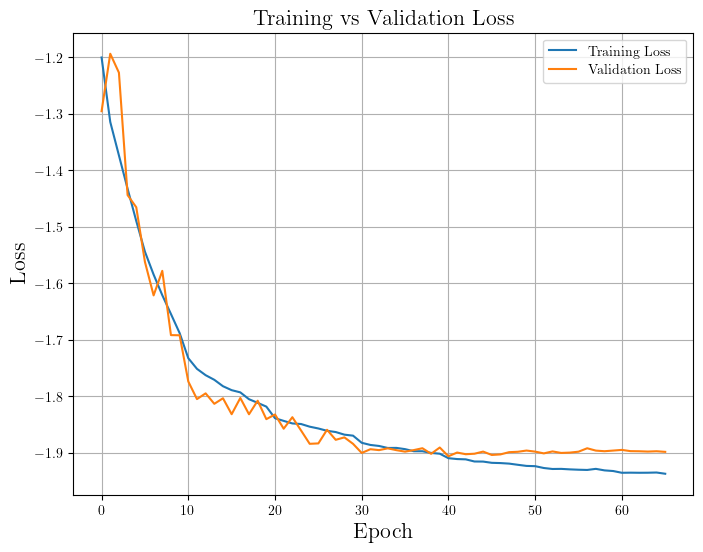

In [29]:
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.title("Training vs Validation Loss", fontsize = 16)
plt.legend()
plt.grid(True)
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [30]:
# import time
# model.eval()
# preds_mu = []
# preds_std = []
# targets = []
# epistemic = []

# criterion = nn.MSELoss(reduction="none")
# i = 0
# with torch.no_grad():
#     for xb, yb in test_loader:   # <-- use test_loader here
#         # print(f"batch {i}")
#         # i += 1
#         # xb = xb.to(device)
#         xb, xout = xb[0].to(device), xb[1].to(device)
#         # yb, _ = yb[0].to(device), yb[1]
#         yb, paths = yb[0].to(device), yb[1]

#         optimizer.zero_grad()

#         # ---- Forward pass ----
#         # Sampling 
#         # start = time.time()
#         # out_lens = model.forward_unet(xb)
#         # muu = model.forward_resnet(out_lens)
#         muu = model(xb)
#         preds_mu.append(muu.cpu())
#         # preds_std.append(logvvv.cpu())
#         # epistemic.append(ouuts.std(axis = 2))
#         targets.append(yb.cpu())

# # concatenate all batches
# preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
# # preds_std = np.concatenate(preds_std, axis = 0)
# # epistemic = np.concatenate(epistemic, axis = 0)
# targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

In [31]:
import time
model.eval()
preds_mu = []
preds_std = []
targets = []
epistemic = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        print(f"batch {i}")
        i += 1
        # xb = xb.to(device)
        xb, xout = xb[0].to(device), xb[1].to(device)
        # xb = xb[:,:-1,:,:]
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        start = time.time()
        muu, logvvv = model(xb)
        preds_mu.append(muu.cpu())
        preds_std.append(logvvv.cpu())
        # epistemic.append(ouuts.std(axis = 2))
        targets.append(yb.cpu())

# concatenate all batches
preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
preds_std = np.concatenate(preds_std, axis = 0)
# epistemic = np.concatenate(epistemic, axis = 0)
targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

batch 0
batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26


KeyboardInterrupt: 

In [31]:
preds_std

array([[-5.231218 , -3.6244004, -3.6169453, -5.857734 , -6.       ],
       [-3.2819467, -3.3866923, -3.4749289, -6.       , -6.       ],
       [-5.605129 , -3.5304487, -3.5226803, -5.994256 , -6.       ],
       ...,
       [-4.7975144, -3.4379961, -3.45861  , -5.79565  , -5.9773526],
       [-6.       , -3.5710602, -3.5624948, -6.       , -6.       ],
       [-5.2748494, -3.5335853, -3.5552564, -6.       , -6.       ]],
      dtype=float32)

In [32]:
np.sqrt(np.exp(preds_std))

array([[0.07312325, 0.16329446, 0.16390428, 0.05345756, 0.04978707],
       [0.19379131, 0.18390313, 0.17596601, 0.04978707, 0.04978707],
       [0.06065432, 0.17114839, 0.17181446, 0.04993026, 0.04978707],
       ...,
       [0.09083077, 0.17924565, 0.17740767, 0.05514302, 0.05035404],
       [0.04978707, 0.16770813, 0.16842791, 0.04978707, 0.04978707],
       [0.07154528, 0.17088018, 0.1690386 , 0.04978707, 0.04978707]],
      dtype=float32)

In [33]:
from torch.utils.data import random_split, DataLoader

dataset = val_loader.dataset  # <-- extract dataset

full_size = len(dataset)
cal_size = int(0.3 * full_size)
test_size = full_size - cal_size

cal_dataset, test_dataset = random_split(dataset, [cal_size, test_size])

cal_loader = DataLoader(cal_dataset, batch_size=val_loader.batch_size, shuffle=False)
cal_test_loader = DataLoader(test_dataset, batch_size=val_loader.batch_size, shuffle=False)

In [34]:
import torch

mus, sigmas, errors, target = [], [], [], []

model.eval()
with torch.no_grad():
    for xb, yb in cal_loader:
        # xb = xb.to(device)
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb[0].to(device)

        mu, std = model(xb)

        # sigma = torch.exp(0.5 * log_var)

        mus.append(mu.cpu())
        target.append(yb.cpu())
        sigmas.append(std.cpu())
        errors.append((yb.cpu() - mu.cpu())**2)

mus = torch.cat(mus).numpy()
target = torch.cat(target).numpy()
sigmas = torch.cat(sigmas).numpy()
errors = torch.cat(errors).numpy()

In [35]:
def beta_func(x, a, b, c):
    return 1.0 / (1.0 + np.exp(-c * (x - a))) ** b

In [36]:
np.sqrt(np.exp(sigmas))

array([[0.05654458, 0.16264407, 0.16296801, 0.04978707, 0.04978707],
       [0.08323988, 0.17462078, 0.1721426 , 0.04978707, 0.04978707],
       [0.04978707, 0.15910429, 0.16059987, 0.04978707, 0.04978707],
       ...,
       [0.06631675, 0.17726642, 0.17532805, 0.04978707, 0.04978707],
       [0.12143961, 0.18047723, 0.17926918, 0.10122032, 0.08026996],
       [0.04978707, 0.1566735 , 0.16003059, 0.04978707, 0.04978707]],
      dtype=float32)

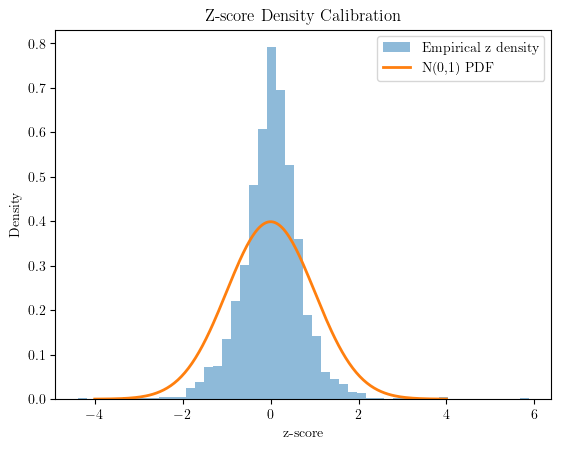

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = mus.detach().cpu().numpy() if hasattr(mus, "detach") else mus
sigma = sigmas.detach().cpu().numpy() if hasattr(sigmas, "detach") else sigmas
sigma = np.sqrt(np.exp(sigma))
y = target
ii = 0
# z-scores
z = (y[:,ii] - mu[:,ii]) / (1 * sigma[:,ii])
z = z.detach().cpu().numpy() if hasattr(z, "detach") else z

# grid for smooth Gaussian curve
x = np.linspace(-4, 4, 200)

plt.figure()

# empirical density
plt.hist(z, bins=50, density=True, alpha=0.5, label="Empirical z density")

# theoretical standard normal
plt.plot(x, norm.pdf(x), label="N(0,1) PDF", linewidth=2)

plt.xlabel("z-score")
plt.ylabel("Density")
plt.title("Z-score Density Calibration")
plt.legend()
plt.show()

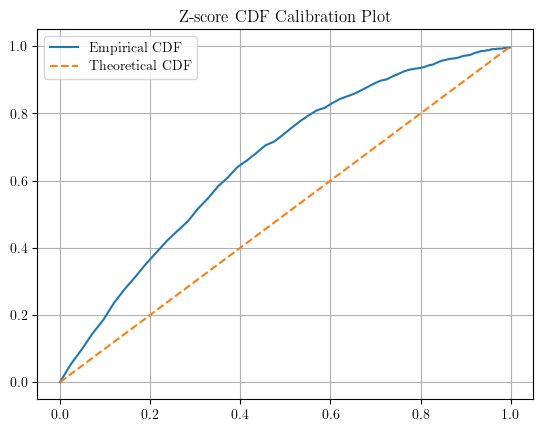

CDF calibration error: 0.10023080721090467


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


# convert to numpy if needed
mu = mus.detach().cpu().numpy() if hasattr(mus, "detach") else mus
sigma = sigmas.detach().cpu().numpy() if hasattr(sigmas, "detach") else sigmas
sigma = np.sqrt(np.exp(sigma))
y = target
ii = 0
# compute z-scores
z = (y[:,ii] - mu[:,ii]) / (1* sigma[:,ii])
z_abs = np.abs(z)

# grid of thresholds
k_values = np.linspace(0, 3, 100)

empirical_cdf = []
theoretical_cdf = []

for k in k_values:
    empirical_cdf.append(np.mean(z_abs <= k))

    # CDF of |Z| where Z ~ N(0,1)
    theoretical_cdf.append(2 * norm.cdf(k) - 1)

empirical_cdf = np.array(empirical_cdf)
theoretical_cdf = np.array(theoretical_cdf)

# plot
plt.figure()

plt.plot(theoretical_cdf, empirical_cdf, label="Empirical CDF")
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), linestyle="--", label="Theoretical CDF")

# plt.xlabel("|z| threshold")
# plt.ylabel("P(|z| ≤ k)")
plt.title("Z-score CDF Calibration Plot")
plt.grid(True)
plt.legend()
plt.show()

# scalar calibration error
calibration_error = np.mean(np.abs(empirical_cdf - theoretical_cdf))
print("CDF calibration error:", calibration_error)

In [39]:
from scipy.optimize import curve_fit

p0 = [1.0, 1.0, 1.0]  # initial guess

params, _ = curve_fit(
    beta_func,
    k_values,
    empirical_cdf,
    p0=p0,
    maxfev=10000
)

a, b, c = params

In [40]:
def calibration_loss(s):
    z_scaled = (y - mu) / (s * sigma)
    z_abs_scaled = np.abs(z_scaled)

    emp = []
    for k in k_values:
        emp.append(np.mean(z_abs_scaled <= k))
    emp = np.array(emp)

    return np.mean((emp - theoretical_cdf) ** 2)

# grid search (robust + simple)
s_grid = np.linspace(0, 4, 1000)
losses = [calibration_loss(s) for s in s_grid]

s_opt = s_grid[np.argmin(losses)]

print("Optimal uncertainty scale s:", s_opt)

Optimal uncertainty scale s: 0.7567567567567568


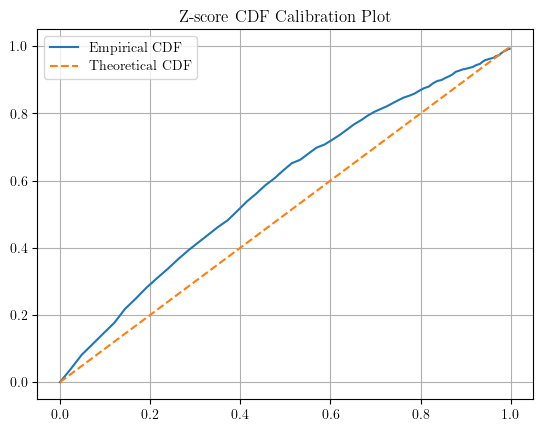

CDF calibration error: 0.05063308590966628


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


# convert to numpy if needed
mu = mus.detach().cpu().numpy() if hasattr(mus, "detach") else mus
sigma = sigmas.detach().cpu().numpy() if hasattr(sigmas, "detach") else sigmas
sigma = np.sqrt(np.exp(sigma))
y = target
ii= 0
# compute z-scores
z = (y[:,ii] - mu[:,ii]) / (s_opt * sigma[:,ii])
z_abs = np.abs(z)

# grid of thresholds
k_values = np.linspace(0, 3, 100)

empirical_cdf = []
theoretical_cdf = []

for k in k_values:
    empirical_cdf.append(np.mean(z_abs <= k))

    # CDF of |Z| where Z ~ N(0,1)
    theoretical_cdf.append(2 * norm.cdf(k) - 1)

empirical_cdf = np.array(empirical_cdf)
theoretical_cdf = np.array(theoretical_cdf)

# plot
plt.figure()

plt.plot(theoretical_cdf, empirical_cdf, label="Empirical CDF")
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), linestyle="--", label="Theoretical CDF")

# plt.xlabel("|z| threshold")
# plt.ylabel("P(|z| ≤ k)")
plt.title("Z-score CDF Calibration Plot")
plt.grid(True)
plt.legend()
plt.show()

# scalar calibration error
calibration_error = np.mean(np.abs(empirical_cdf - theoretical_cdf))
print("CDF calibration error:", calibration_error)

In [42]:
import time
model.train()
preds_mu = []
preds_std = []
targets = []
epistemic = []
PPP = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        print(f"batch {i}")
        i += 1
        
        # xb = xb.to(device)
        # xb = xb[:,:-1,:,:]
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        start = time.time()
        ouuts = np.stack(
            [model(xb)[0].cpu() for _ in range(100)],
            axis=2)
        print(time.time() - start)
        preds_mu.append(model(xb)[0].cpu())
        preds_std.append(model(xb)[1].cpu())
        epistemic.append(ouuts.std(axis = 2))
        targets.append(yb.cpu())
        PPP += [p for p in paths]

# concatenate all batches
preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
preds_std = np.concatenate(preds_std, axis = 0)
epistemic = np.concatenate(epistemic, axis = 0)
targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

batch 0
9.844466209411621
batch 1
9.829225778579712
batch 2
9.837831497192383
batch 3
9.83962106704712
batch 4
9.84492540359497
batch 5
9.84726071357727
batch 6


KeyboardInterrupt: 

In [ ]:
# --- Compute R2 per parameter ---
y_true_np = targets
y_pred_np = preds_mu
preds_std_np = preds_std
epistemic_np =epistemic

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)

In [ ]:
cols = ["r_Einstein_t", "gamma1", "gamma2", "ex", "ey"]

df_uncertainties = pd.concat(
    [
        pd.DataFrame(targets, columns=[f"{c}_true" for c in cols]),
        pd.DataFrame(preds_mu, columns=[f"{c}_pred" for c in cols]),
        pd.DataFrame(preds_std, columns=[f"{c}_aleatoric" for c in cols]),
        pd.DataFrame(epistemic, columns=[f"{c}_epistemic" for c in cols]),
        pd.DataFrame({"Paths" : PPP})
    ],
    axis=1,
)

In [ ]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

df_uncertainties.to_csv('uncertainties_bayes_unetresnet.csv')

In [ ]:
print(eeeeeeeeeeeeeeeeeeeeeee)

In [ ]:
df_uncertainties = pd.read_csv('uncertainties_bayes.csv', index_col = 0)

In [32]:
df_uncertainties = pd.read_csv('uncertainties_bayes_unetresnet.csv', index_col = 0)

In [33]:
df_uncertainties

,r_Einstein_t_true,gamma1_true,gamma2_true,ex_true,ey_true,r_Einstein_t_pred,gamma1_pred,gamma2_pred,ex_pred,ey_pred,...,gamma1_aleatoric,gamma2_aleatoric,ex_aleatoric,ey_aleatoric,r_Einstein_t_epistemic,gamma1_epistemic,gamma2_epistemic,ex_epistemic,ey_epistemic,Paths
0,0.895991,0.421908,0.407725,0.384821,0.506791,0.916155,0.484182,0.519076,0.411868,0.519494,...,-3.541714,-3.572762,-5.796578,-5.909351,0.055250,0.008105,0.007236,0.029963,0.021405,final_hscsearch_2e3_3/lens_4865_source_989_r_1...
1,0.006785,0.498224,0.496970,0.466943,0.435864,0.239473,0.501319,0.508492,0.514243,0.417257,...,-3.428656,-3.504149,-6.000000,-6.000000,0.052306,0.003855,0.005557,0.015529,0.015057,final_hscsearch_2e3_26/lens_51981_source_1123_...
2,0.177612,0.512140,0.639151,0.612127,0.514790,0.186001,0.499588,0.503283,0.586064,0.498957,...,-3.587909,-3.556348,-5.941519,-6.000000,0.043260,0.006915,0.005629,0.022624,0.018241,final_hscsearch_2e3_22/lens_43478_source_1268_...
3,0.085871,0.543400,0.480554,0.505455,0.499035,0.181359,0.514431,0.493778,0.546687,0.493154,...,-3.671822,-3.620020,-6.000000,-6.000000,0.062778,0.004967,0.005534,0.014108,0.014415,final_hscsearch_2e3_24/lens_47293_source_50_r_...
4,0.779045,0.920428,0.639357,0.721708,0.539079,0.799251,0.509544,0.521260,0.549111,0.594405,...,-3.624749,-3.610375,-5.911696,-6.000000,0.034578,0.005782,0.006634,0.017728,0.019338,final_hscsearch_2e3_6/lens_10952_source_385_r_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8741,0.925814,0.278565,0.337357,0.511276,0.456869,0.807083,0.489291,0.514590,0.501419,0.453745,...,-3.544328,-3.560668,-6.000000,-6.000000,0.050699,0.004030,0.005497,0.013799,0.017881,final_hscsearch_2e3_2/lens_3924_source_3723_r_...
8742,0.703916,0.515615,0.821545,0.302522,0.345264,0.595752,0.465978,0.485642,0.317440,0.456791,...,-3.515425,-3.506597,-4.952440,-5.220201,0.032799,0.011020,0.007924,0.033865,0.032226,final_hscsearch_2e3_9/lens_16127_source_426_r_...
8743,0.533192,0.989708,0.569939,0.578675,0.403395,0.464088,0.515283,0.489308,0.641709,0.418571,...,-3.437038,-3.418680,-5.701505,-5.909953,0.025496,0.008608,0.006653,0.025675,0.016381,final_hscsearch_2e3_13/lens_24583_source_2069_...
8744,0.483549,0.671676,0.701700,0.495656,0.502268,0.482209,0.505559,0.514415,0.515235,0.545285,...,-3.637511,-3.617396,-6.000000,-6.000000,0.014795,0.004401,0.003827,0.010053,0.011568,final_hscsearch_2e3_14/lens_27995_source_6292_...


In [34]:
# y_true = targets 
# y_pred = preds_mu 

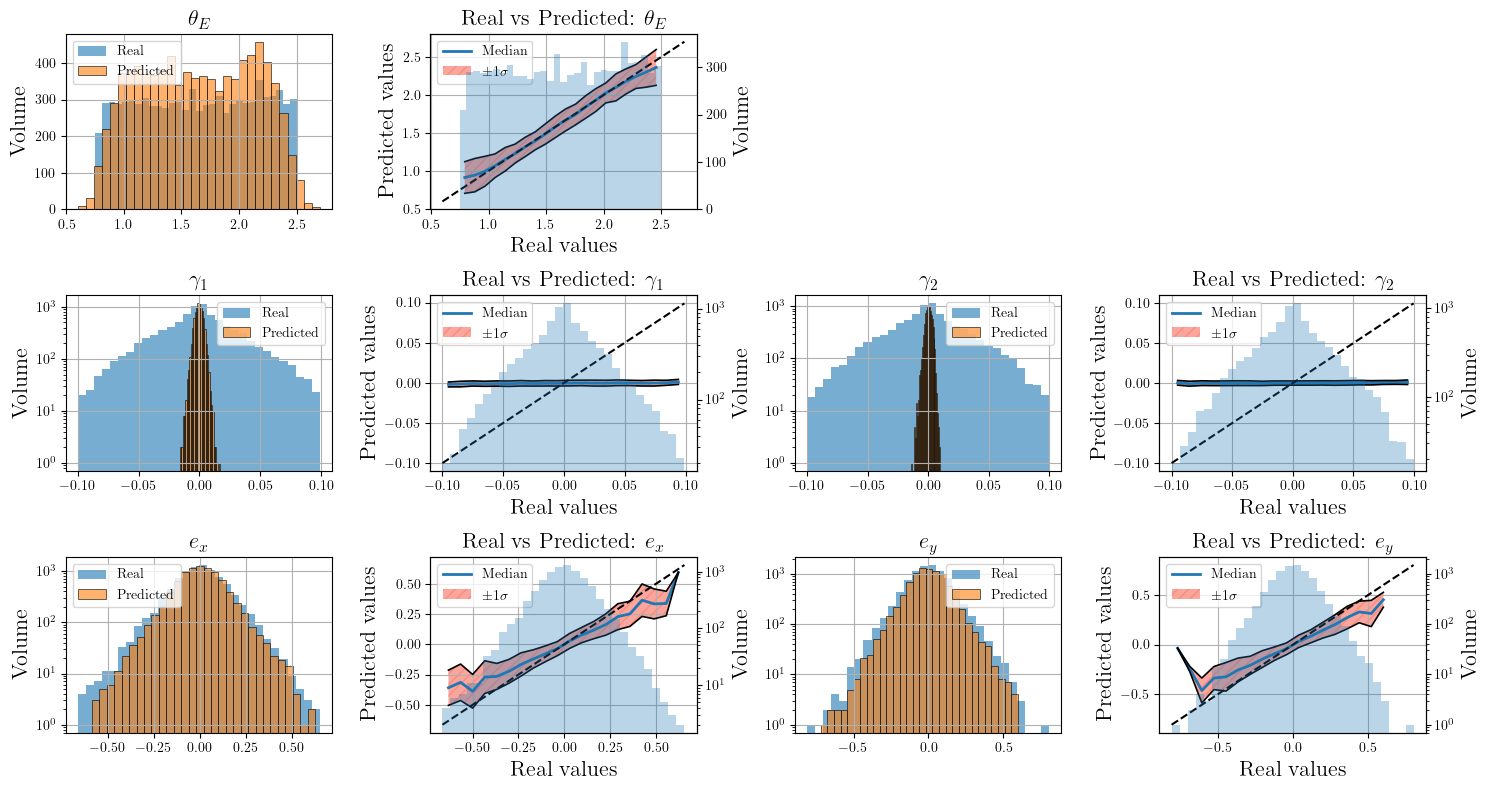

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

# y_true = targets 
# y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_1$", r"$\gamma_2$", r"$e_x$", r"$e_y$"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    if i == 0: 
        plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
        plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    else : 
        plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real", log = True)
        plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7, log = True)
    plt.title(f"{param_names[i]}", fontsize = 16)
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values", fontsize = 16)
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$\pm 1 \sigma$"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    if i == 0 :
        ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    else :
        ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3, log = True)
    ax2.set_ylabel("Volume", fontsize = 16)
    
    ax1.set_xlabel("Real values", fontsize = 16)
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}", fontsize = 16)
#     plt.grid(True)
#     plt.legend()


PPP = [(1,2), (5,6), (9,10)]
for jj in PPP:
    ax1 = plt.subplot(3, 4,  jj[0])
    ax1.set_ylabel('Volume', fontsize = 16)
plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unetresnet_results.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
# y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
# y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

y_true = targets 
y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true = y_true * (df_max - df_min) + df_min
y_pred = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\Delta \ \theta_E$", r"$\Delta \ \gamma_1$", r"$\Delta \ \gamma_2$", r"$\Delta \ e_x$", r"$\Delta \ e_y$"]

y_true = np.array(y_true)
y_pred = np.array(y_pred)

residuals = y_pred - y_true   # shape: (N, 5)
n_params = residuals.shape[1]

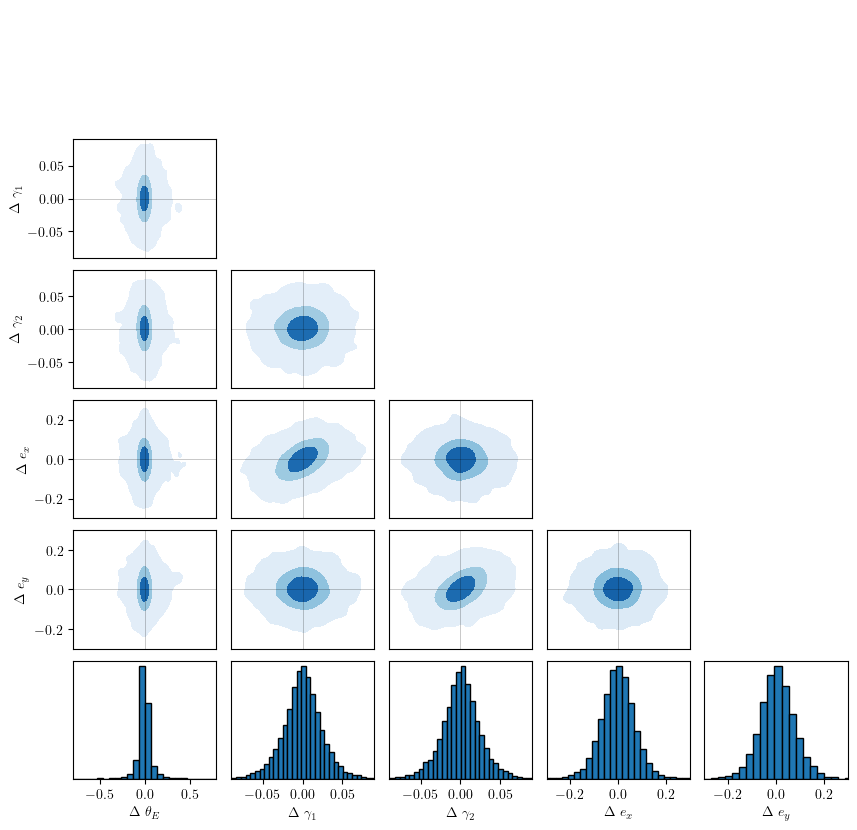

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

fig, axes = plt.subplots(n_params + 1, n_params, figsize=(10, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        if i > j:
            # KDE contours
            sns.kdeplot(
                x=residuals[:, j],
                y=residuals[:, i],
                levels=4,
                linewidths=1.2,
                color = 'black',
                cmap="Blues",
                fill=True,
                alpha=1,
                ax=ax
            )

            # zero reference lines (VERY useful visually)
            ax.axhline(0, color="black", lw=0.5, alpha=0.3)
            ax.axvline(0, color="black", lw=0.5, alpha=0.3)
        else:
            ax.axis("off")
        if i < 3:
            ax.set_ylim([-0.09, 0.09])
        else : 
            ax.set_ylim([-0.3, 0.3])
        if j == 0:
            ax.set_xlim([-0.8, 0.8])
        elif j < 3:
            ax.set_xlim([-0.09, 0.09])
        else:
            ax.set_xlim([-0.3, 0.3])

        # axis labels (FIXED CONDITION)
        if i == n_params :
            ax.set_xlabel(param_names[j], fontsize = 16)
        else:
            ax.set_xticks([])

        if j == 0 and i != j:
            ax.set_ylabel(param_names[i])
        else:
            ax.set_yticks([])
            

# bottom row histograms
for k in range(n_params):
    ax = axes[-1, k]
    ax.hist(residuals[:, k], bins=40, edgecolor="black")
    ax.set_xlabel(param_names[k])
    ax.set_yticks([])
    if k == 0:
        ax.set_xlim([-0.8, 0.8])
    elif k < 3:
        ax.set_xlim([-0.09, 0.09])
    else:
        ax.set_xlim([-0.3, 0.3])

plt.show()

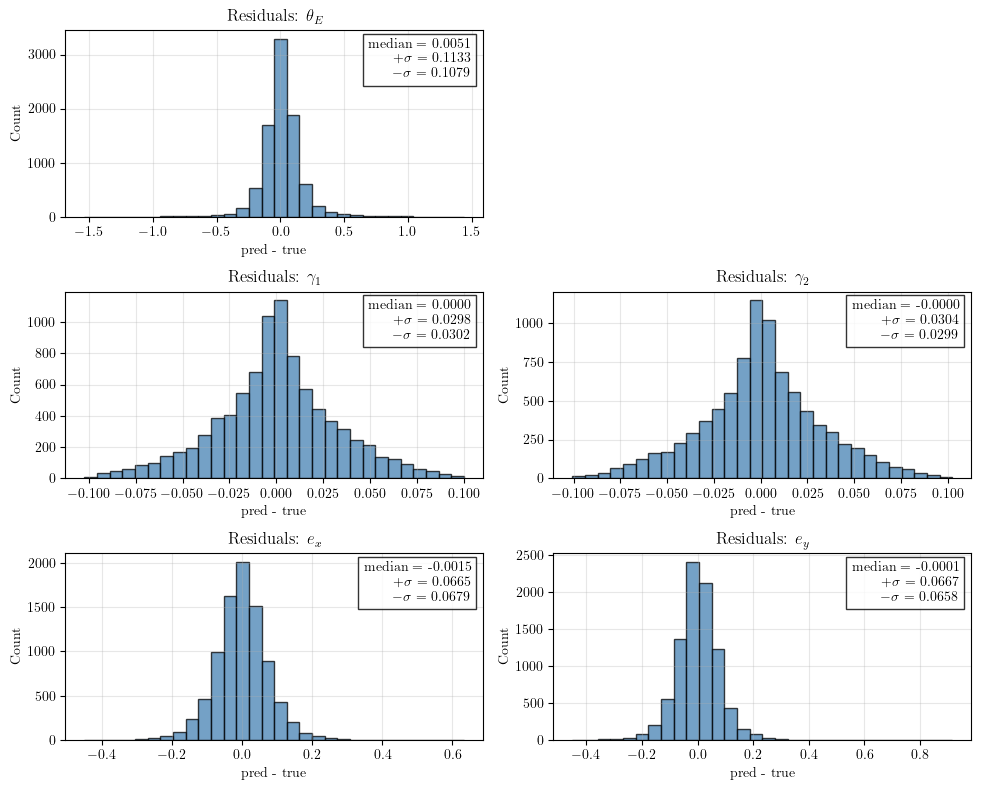

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # Convert to numpy
y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values


# y_true = targets 
# y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_1$", r"$\gamma_2$", r"$e_x$", r"$e_y$"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("pred - true")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"$+ \sigma$ = {sigma_plus[i]:.4f}\n"
        f"$- \sigma$ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.95, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

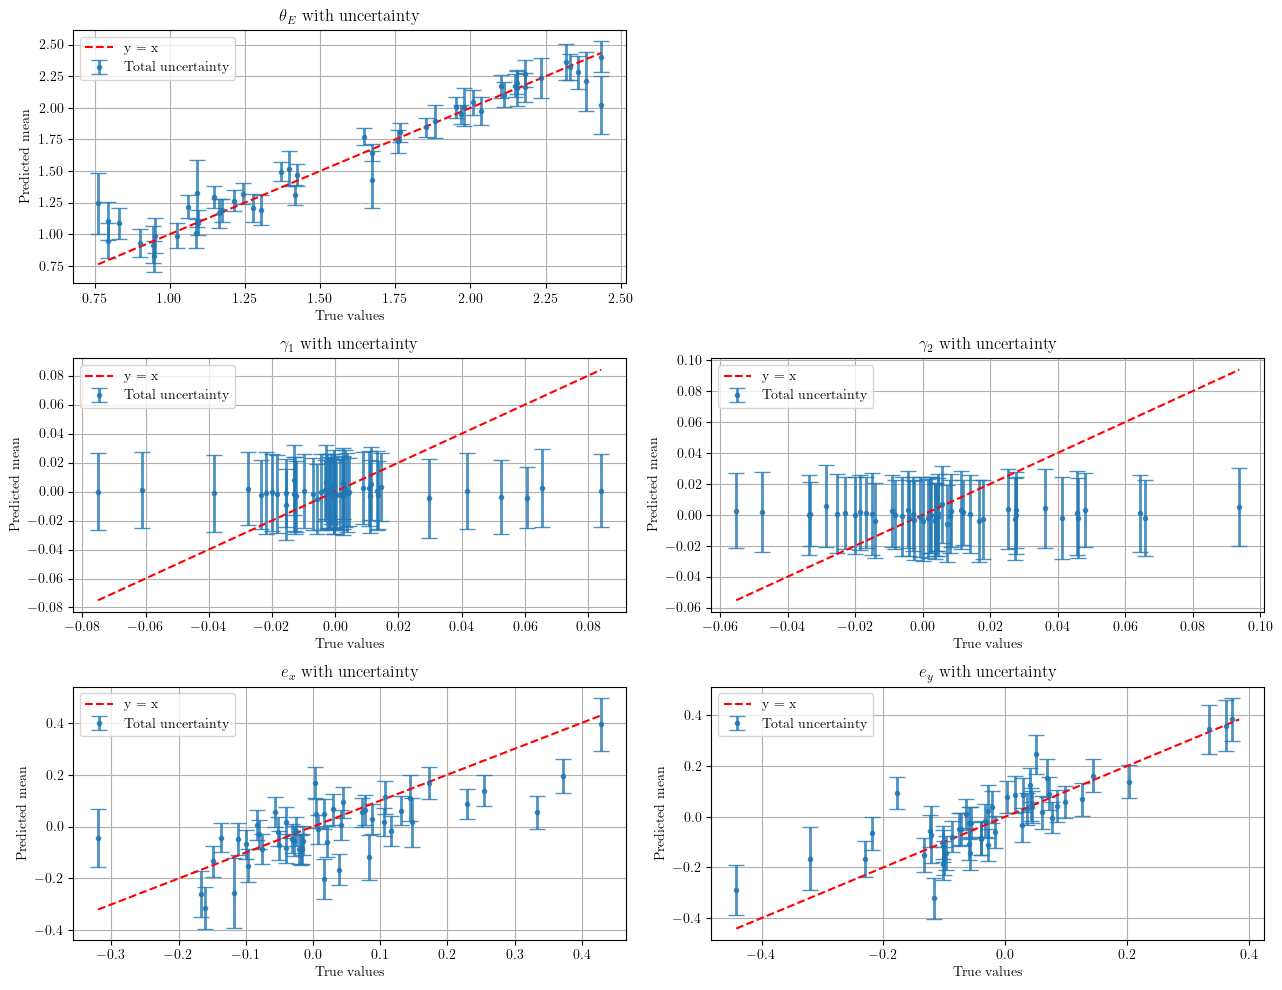

In [47]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_1$", r"$\gamma_2$", r"$e_x$", r"$e_y$"]
V = 50

plt.figure(figsize=(13, 10))
places = [1,3,4,5,6]

all_aleatoric = df_uncertainties[['r_Einstein_t_aleatoric', 'gamma1_aleatoric', 'gamma2_aleatoric',
       'ex_aleatoric', 'ey_aleatoric']].values
all_epistemic = df_uncertainties[['r_Einstein_t_epistemic',
       'gamma1_epistemic', 'gamma2_epistemic', 'ex_epistemic', 'ey_epistemic']].values

all_aleatoric = s_opt * np.sqrt(np.exp(all_aleatoric)) * (df_max - df_min)
all_epistemic = all_epistemic * (df_max - df_min)
unc_tot = np.sqrt(all_aleatoric**2 + all_epistemic**2)

for i in range(5):
    
    true_values = y_true_denorm[:V,i]
    pred_mean = y_pred_denorm[:V,i]
    pred_epis = all_epistemic[:V,i]
    pred_alea = all_aleatoric[:V,i]
    unc_tot_i = unc_tot[:V,i]

#     plt.figure(figsize=(12,6))
    plt.subplot(3, 2, places[i])

    # Scatter points
#     plt.scatter(true_values, pred_mean, color='blue', alpha=0.7, label='Predictions')

    # Uncertainty bars (vertical)
    plt.errorbar(true_values, pred_mean, 
                 yerr=unc_tot_i, 
                 fmt='o', 
                 markersize=3,
                 alpha=0.8, 
                 capsize=6,
                label = 'Total uncertainty', linewidth = 2)
    
    # plt.errorbar(true_values, pred_mean, 
    #              yerr=pred_alea, 
    #              fmt='o', 
    #              markersize=3,
    #              alpha=0.55, 
    #              capsize=6,
    #             label = 'Aleatoric', linewidth = 2)

    # Reference y=x line
    min_val = min(true_values.min(), pred_mean.min())
    max_val = max(true_values.max(), pred_mean.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
    plt.xlabel("True values")
    plt.ylabel("Predicted mean")
    plt.title(f"{param_names[i]} with uncertainty")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/uncertainty_para.png", dpi=300, bbox_inches="tight")
plt.show()


In [51]:
(df_max - df_min)

array([1.74994198, 0.19998031, 0.19982033, 1.46756378, 1.66341667])

In [52]:
all_epistemic

array([[0.09352362, 0.00196506, 0.00156784, 0.04766506, 0.02583985],
       [0.08438574, 0.00057858, 0.00110529, 0.01919325, 0.02053645],
       [0.06818917, 0.0013038 , 0.00143032, 0.03062398, 0.02959328],
       ...,
       [0.04307241, 0.00140006, 0.00143782, 0.02637203, 0.02362579],
       [0.03019363, 0.0008697 , 0.0010009 , 0.01627432, 0.0212455 ],
       [0.08739409, 0.00095231, 0.00163941, 0.03039594, 0.02422075]])

In [53]:
all_aleatoric

array([[0.10695146, 0.0249052 , 0.02497855, 0.0654538 , 0.06979484],
       [0.23068382, 0.02825564, 0.02638017, 0.05412274, 0.06134566],
       [0.06453665, 0.02514503, 0.02545546, 0.05412274, 0.06134566],
       ...,
       [0.06453665, 0.02462063, 0.02454278, 0.05412274, 0.06134566],
       [0.06453665, 0.02504747, 0.02457308, 0.05412274, 0.06134566],
       [0.08014953, 0.0254922 , 0.02548958, 0.05412274, 0.06134566]])

In [54]:
df_uncertainties

,r_Einstein_t_true,gamma1_true,gamma2_true,ex_true,ey_true,r_Einstein_t_pred,gamma1_pred,gamma2_pred,ex_pred,ey_pred,...,gamma1_aleatoric,gamma2_aleatoric,ex_aleatoric,ey_aleatoric,r_Einstein_t_epistemic,gamma1_epistemic,gamma2_epistemic,ex_epistemic,ey_epistemic,Paths
0,0.895991,0.421908,0.407725,0.384821,0.506791,0.921582,0.454817,0.508098,0.280618,0.549364,...,-3.566076,-3.558593,-5.619820,-5.741929,0.053444,0.009826,0.007846,0.032479,0.015534,final_hscsearch_2e3_3/lens_4865_source_989_r_1...
1,0.006785,0.498224,0.496970,0.466943,0.435864,0.282222,0.492333,0.494726,0.437411,0.427367,...,-3.313642,-3.449403,-6.000000,-6.000000,0.048222,0.002893,0.005531,0.013078,0.012346,final_hscsearch_2e3_26/lens_51981_source_1123_...
2,0.177612,0.512140,0.639151,0.612127,0.514790,0.267164,0.528318,0.499477,0.607935,0.549647,...,-3.546908,-3.520768,-6.000000,-6.000000,0.038967,0.006520,0.007158,0.020867,0.017791,final_hscsearch_2e3_22/lens_43478_source_1268_...
3,0.085871,0.543400,0.480554,0.505455,0.499035,0.103666,0.511181,0.489825,0.527444,0.544558,...,-3.524996,-3.539559,-6.000000,-6.000000,0.047801,0.003985,0.008323,0.013369,0.013644,final_hscsearch_2e3_24/lens_47293_source_50_r_...
4,0.779045,0.920428,0.639357,0.721708,0.539079,0.772958,0.503325,0.516082,0.531731,0.589496,...,-3.515219,-3.529420,-5.899117,-6.000000,0.035339,0.006483,0.009757,0.019694,0.025439,final_hscsearch_2e3_6/lens_10952_source_385_r_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8741,0.925814,0.278565,0.337357,0.511276,0.456869,0.896449,0.488741,0.509087,0.445708,0.432574,...,-3.443636,-3.465830,-6.000000,-6.000000,0.048800,0.004537,0.007266,0.012787,0.017060,final_hscsearch_2e3_2/lens_3924_source_3723_r_...
8742,0.703916,0.515615,0.821545,0.302522,0.345264,0.528703,0.470137,0.496585,0.325489,0.435741,...,-3.378386,-3.465906,-5.090407,-5.297354,0.045568,0.008172,0.007501,0.031021,0.023124,final_hscsearch_2e3_9/lens_16127_source_426_r_...
8743,0.533192,0.989708,0.569939,0.578675,0.403395,0.577996,0.522036,0.477171,0.594573,0.430085,...,-3.589059,-3.593793,-6.000000,-6.000000,0.024614,0.007001,0.007196,0.017970,0.014203,final_hscsearch_2e3_13/lens_24583_source_2069_...
8744,0.483549,0.671676,0.701700,0.495656,0.502268,0.504376,0.501456,0.522163,0.501861,0.560369,...,-3.554683,-3.591325,-6.000000,-6.000000,0.017254,0.004349,0.005009,0.011089,0.012772,final_hscsearch_2e3_14/lens_27995_source_6292_...


In [55]:
sigma

array([[0.08181613, 0.18085055, 0.17663427, 0.05576364, 0.04978707],
       [0.04978707, 0.17369275, 0.17249838, 0.04978707, 0.04978707],
       [0.05148164, 0.16085935, 0.15902798, 0.04978707, 0.04978707],
       ...,
       [0.0778783 , 0.17577413, 0.17300394, 0.04978707, 0.04978707],
       [0.28147107, 0.18626055, 0.18033995, 0.09616537, 0.07955237],
       [0.05112443, 0.17289399, 0.17299846, 0.04978707, 0.04978707]],
      dtype=float32)

In [56]:
df_uncertainties.r_Einstein_t_true[index]* 1.75

NameError: name 'index' is not defined

In [57]:
df_uncertainties.r_Einstein_t_pred[index] * 1.75

NameError: name 'index' is not defined

In [58]:
std_alea**2

NameError: name 'std_alea' is not defined

In [59]:
sigma

array([[0.08181613, 0.18085055, 0.17663427, 0.05576364, 0.04978707],
       [0.04978707, 0.17369275, 0.17249838, 0.04978707, 0.04978707],
       [0.05148164, 0.16085935, 0.15902798, 0.04978707, 0.04978707],
       ...,
       [0.0778783 , 0.17577413, 0.17300394, 0.04978707, 0.04978707],
       [0.28147107, 0.18626055, 0.18033995, 0.09616537, 0.07955237],
       [0.05112443, 0.17289399, 0.17299846, 0.04978707, 0.04978707]],
      dtype=float32)

In [60]:
np.random.randint(0,8000,18)

array([7270, 7603,  860, 5390, 5226, 5191, 3772, 3092, 5734, 6265,  466,
       5334, 4426, 5578, 6231, 3444, 3171, 2919])

In [52]:
pwd

'/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing'

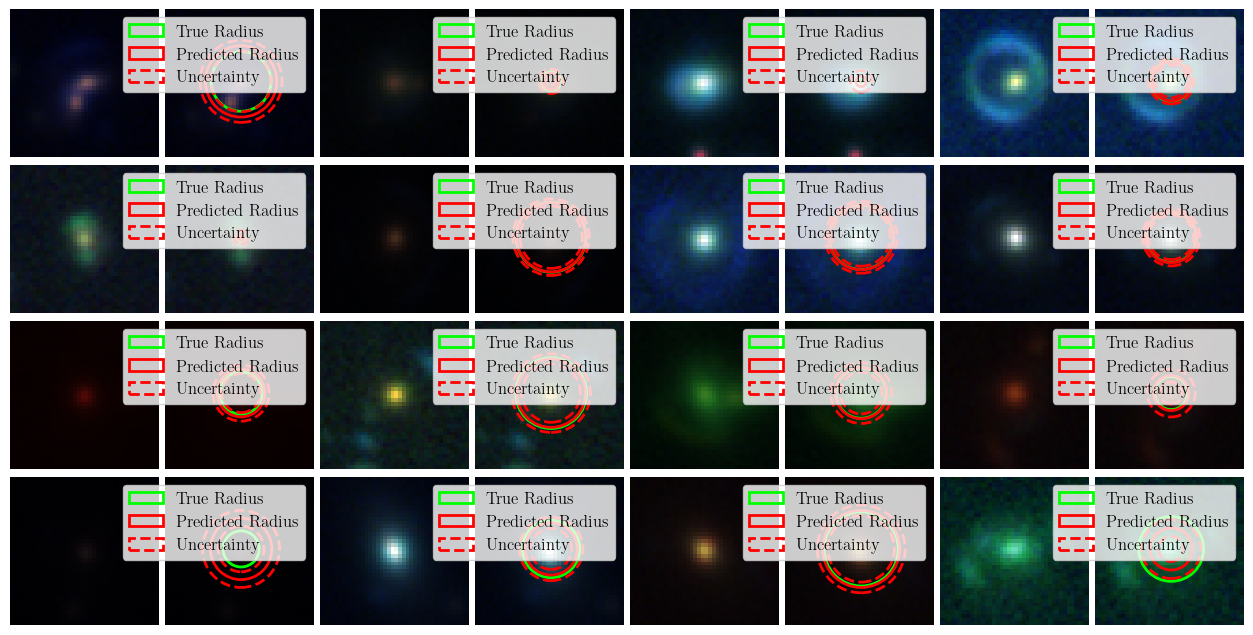

In [53]:
indexx = np.random.randint(0,8000,16)

fig, axis = plt.subplots(4,8, figsize = (16,8))
fig.subplots_adjust(wspace=0.001, hspace=0.05)
axis = axis.flatten()
d = 0
for k in range(len(indexx)):
    index = indexx[k]
    folder = "/home/rcanameras/data/mock_lenses_hsc"
    file = os.path.join(folder, df_uncertainties.Paths[index])
    # print("Opening:", file)
    
    true_value = df_uncertainties.r_Einstein_t_true[index]* 1.75
    pred_value = df_uncertainties.r_Einstein_t_pred[index] * 1.75
    std_alea = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric[index])) * 2.75 
    sigma = np.sqrt(std_alea**2 + (df_uncertainties.r_Einstein_t_epistemic[index] * 1.75)**2) 
    # sigma = np.sqrt(df_uncertainties.r_Einstein_t_aleatoric[index]**2)  * s_opt * 1.75
    
    with fits.open(file) as hdul:
        images = [hdul[i].data for i in range(1, len(hdul))]
    images = images[::2]
    # fig, axes = plt.subplots(1, 4, figsize=(15, 10))
    bandes = ['g', 'r', 'i', 'z']
    
    w1, w2 = 100, 60 # image will be of dimension w2-w1 x w2-w1
    
    with fits.open(file) as hdul:
        g = hdul[1].data
        r = hdul[3].data
        i = hdul[5].data
        z = hdul[7].data
        
    R, G, B = i, r, g
    
    def norm(x):
        x = x - np.nanmin(x)
        x = x / np.nanmax(x)
        return x
    
    Rn, Gn, Bn = norm(R)[w1:-w1,w1:-w1], norm(G)[w1:-w1,w1:-w1], norm(B)[w1:-w1,w1:-w1]
    
    rgb = np.dstack([Rn, Gn, Bn])
    
    axis[d].imshow(rgb, origin='lower')
    # axis[d].set_title("Lensing image")
    axis[d].axis('off')
    
    # Right image
    axis[d +1].imshow(rgb, origin='lower')
    # axis[d +1].set_title("Radius Comparison")
    axis[d +1].axis('off')
    
    H, W = rgb.shape[:2]
    cx, cy = W/2, H/2
    
    # True Einstein radius (green)
    circle_true = plt.Circle(
        (cx, cy),
        true_value/ 0.168,
        color='lime',
        fill=False,
        linewidth=2,
        label='True Radius'
    )
    axis[d+1].add_patch(circle_true)
    
    # Predicted Einstein radius (red)
    circle_pred = plt.Circle(
        (cx, cy),
        pred_value/ 0.168,
        color='red',
        fill=False,
        linewidth=2,
        label='Predicted Radius'
    )
    axis[d +1].add_patch(circle_pred)
    
    # Predicted Einstein radius (red)
    circle_pred_sig_p = plt.Circle((cx, cy), pred_value/0.168 + sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--')
    axis[d +1].add_patch(circle_pred_sig_p)
    
    # Predicted Einstein radius (red)
    circle_pred_m = plt.Circle((cx, cy), pred_value/0.168 - sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--', label='Uncertainty')
    axis[d +1].add_patch(circle_pred_m)
    
    # Add legend
    axis[d +1].legend(loc='upper right', fontsize=12)
    d += 2
# plt.tight_layout()
plt.savefig("predspreds.png")
plt.show()

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_17/lens_32956_source_2377_r_0.fits


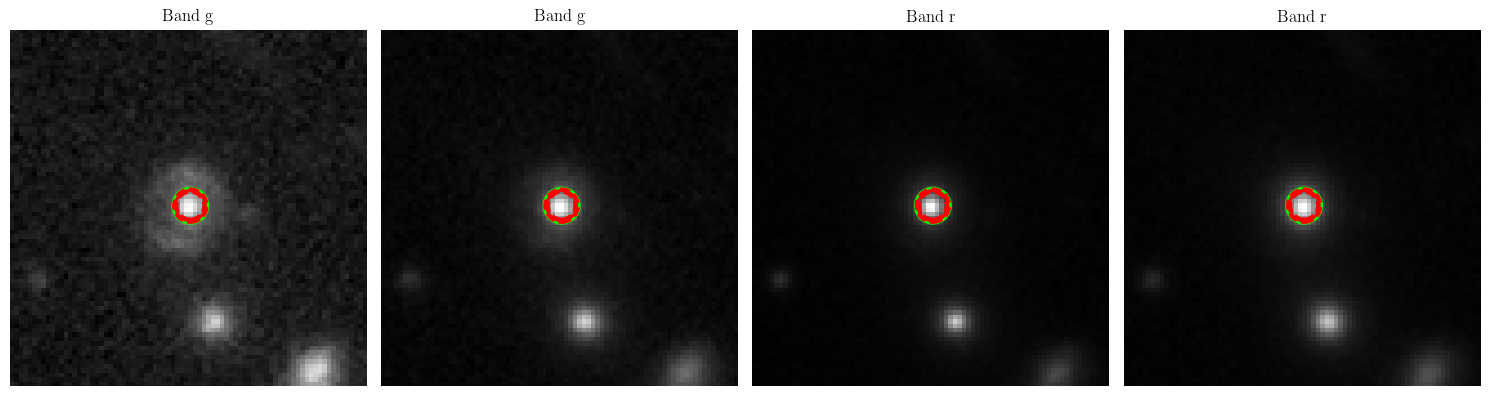

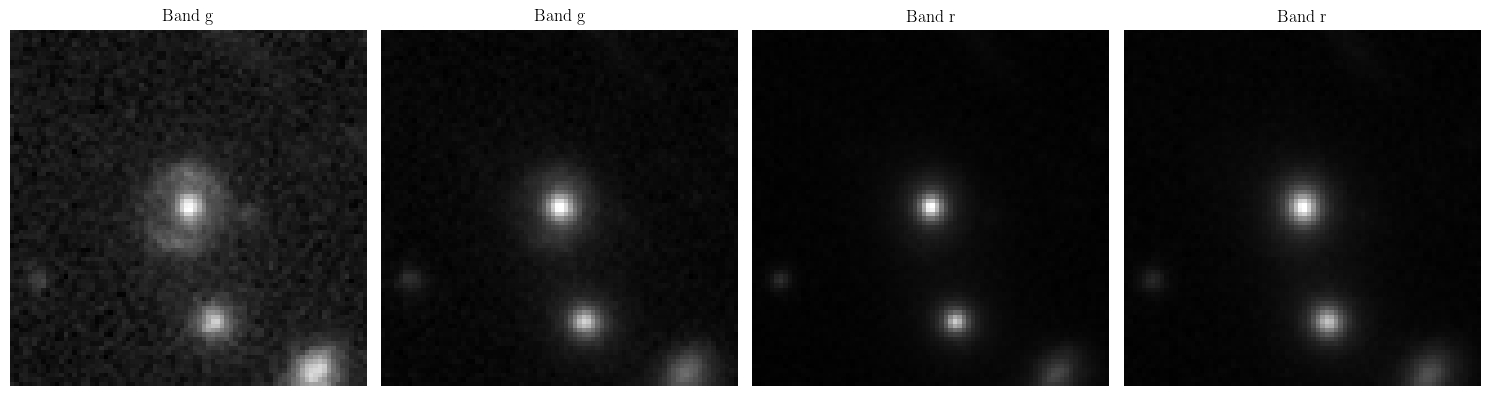

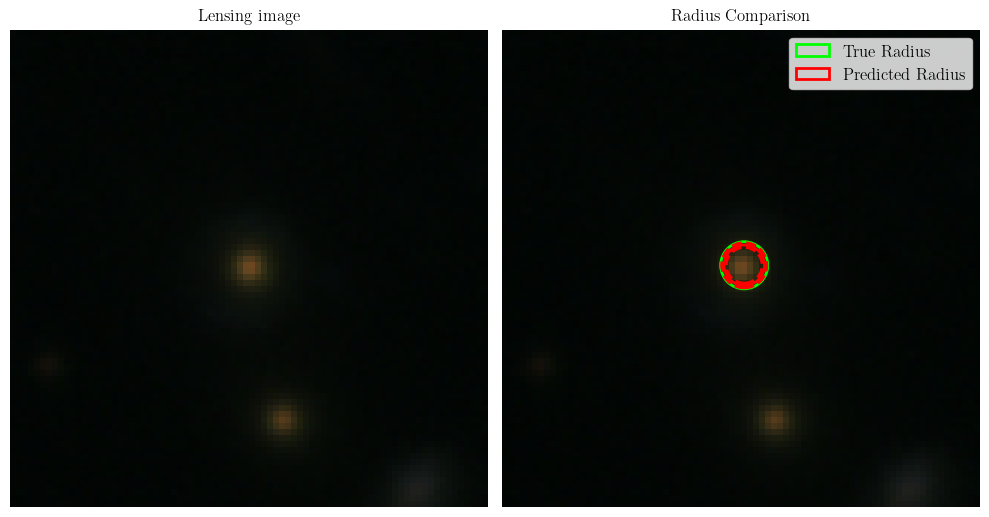

In [93]:
index = 8

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_uncertainties.Paths[index])
print("Opening:", file)


true_value = df_uncertainties.r_Einstein_t_true[index]* 1.75
pred_value = df_uncertainties.r_Einstein_t_pred[index] * 1.75
std_alea = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric[index])) * 1.75 * s_opt
sigma = np.sqrt(std_alea**2 + df_uncertainties.r_Einstein_t_epistemic[index]**2)
# sigma = np.sqrt(df_uncertainties.r_Einstein_t_aleatoric[index]**2)  * s_opt * 1.75

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
images = images[::2]
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']

w1, w2 = 80, 60 # image will be of dimension w2-w1 x w2-w1

for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
    H, W = img.shape
    cx, cy = W/2, H/2

    # True Einstein radius (green)
    circle_true = plt.Circle((cx, cy), true_value/0.168,
                             color='lime', fill=False, linewidth=2)
    ax.add_patch(circle_true)

    # Predicted Einstein radius (red)
    circle_pred = plt.Circle((cx, cy), pred_value/0.168,
                             color='red', fill=False, linewidth=2)
    ax.add_patch(circle_pred)

    # Predicted Einstein radius (red)
    circle_pred_sig_p = plt.Circle((cx, cy), pred_value/0.168 + sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--')
    ax.add_patch(circle_pred_sig_p)

    # Predicted Einstein radius (red)
    circle_pred_m = plt.Circle((cx, cy), pred_value/0.168 - sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--')
    ax.add_patch(circle_pred_m)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R)[w1:-w1,w1:-w1], norm(G)[w1:-w1,w1:-w1], norm(B)[w1:-w1,w1:-w1]

rgb = np.dstack([Rn, Gn, Bn])

fig, axis = plt.subplots(1,2, figsize=(10,10))
axis[0].imshow(rgb, origin='lower')
axis[0].set_title("Lensing image")
axis[0].axis('off')

# Right image
axis[1].imshow(rgb, origin='lower')
axis[1].set_title("Radius Comparison")
axis[1].axis('off')

H, W = img.shape
cx, cy = W/2, H/2

# True Einstein radius (green)
circle_true = plt.Circle(
    (cx, cy),
    true_value/ 0.168,
    color='lime',
    fill=False,
    linewidth=2,
    label='True Radius'
)
axis[1].add_patch(circle_true)

# Predicted Einstein radius (red)
circle_pred = plt.Circle(
    (cx, cy),
    pred_value/ 0.168,
    color='red',
    fill=False,
    linewidth=2,
    label='Predicted Radius'
)
axis[1].add_patch(circle_pred)

# Predicted Einstein radius (red)
circle_pred_sig_p = plt.Circle((cx, cy), pred_value/0.168 + sigma/0.168,
                         color='red', fill=False, linewidth=2, linestyle = '--')
axis[1].add_patch(circle_pred_sig_p)

# Predicted Einstein radius (red)
circle_pred_m = plt.Circle((cx, cy), pred_value/0.168 - sigma/0.168,
                         color='red', fill=False, linewidth=2, linestyle = '--')
axis[1].add_patch(circle_pred_m)


# Add legend
axis[1].legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

In [56]:
sigma

5.626371143510226

In [61]:
import numpy as np

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

scale = (df_max - df_min)

# --- denormalize uncertainties ---
aleatoric_denorm = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric.values)) * 1.75 * s_opt
epistemic_denorm = df_uncertainties.r_Einstein_t_epistemic.values
# epistemic_denorm = 0
sigma_total = np.sqrt(aleatoric_denorm**2 + epistemic_denorm**2)

# --- coverage results -
name = "r_Einstein"
true_value = df_uncertainties.r_Einstein_t_true.values * 1.75
pred_value = df_uncertainties.r_Einstein_t_pred.values * 1.75

true = true_value
pred = pred_value
sigma = sigma_total

inside = np.abs(pred - true) <=  sigma
coverage = inside.mean()

# coverage_results[name] = coverage

print(f"{name}:")
print(f"  coverage (±1σ): {coverage:.3f}")
print(f"  expected ~0.683 for Gaussian\n")

r_Einstein:
  coverage (±1σ): 0.612
  expected ~0.683 for Gaussian



In [69]:
import numpy as np

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

scale = (df_max - df_min)

    std_alea = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric[index])) * 1.75 * s_opt
    sigma = np.sqrt(std_alea**2 + (df_uncertainties.r_Einstein_t_epistemic[index] * 1.75)**2) 

# --- denormalize uncertainties ---
aleatoric_denorm = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric.values)) * 1.75 * s_opt
epistemic_denorm = df_uncertainties.r_Einstein_t_epistemic.values

sigma_total = np.sqrt(aleatoric_denorm**2 + epistemic_denorm**2)

# --- coverage results ---
coverage_results = {}

for i, name in enumerate(param_names):

    true = y_true_denorm[:, i]
    pred = y_pred_denorm[:, i]
    sigma = sigma_total[:, i]

    inside = np.abs(pred - true) <=  sigma
    coverage = inside.mean()

    coverage_results[name] = coverage

    print(f"{name}:")
    print(f"  coverage (±1σ): {coverage:.3f}")
    print(f"  expected ~0.683 for Gaussian\n")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [30]:
y_true_denorm[:, 0]

array([2.31794933, 0.76188982, 1.06082727, ..., 1.68307172, 1.59619844,
       0.87204213])

In [31]:
y_pred_denorm[:, 0]

array([2.36333447, 0.87043438, 1.17867963, ..., 1.48336583, 1.63909813,
       0.9491136 ])

In [32]:
sigma_total[:, 0]

array([0.03439901, 0.01968476, 0.02065361, ..., 0.02372728, 0.03476265,
       0.02199985])

In [34]:
aleatoric_denorm[:,0]

array([0.01179102, 0.01179102, 0.01179102, ..., 0.01179102, 0.01179102,
       0.01179102])

In [35]:
epistemic_denorm[:,0]

array([0.03231507, 0.01576267, 0.0169571 , ..., 0.02059019, 0.03270189,
       0.01857324])

In [33]:
df_max - df_min

array([1.74994198, 0.19998031, 0.19982033, 1.46756378, 1.66341667])

In [ ]:
plt.hist(epistemic_denorm[:, 0], log = True, bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Total uncertainty histogram on the Einstein Radius', fontsize = 18)
plt.xlabel('$\sigma$ Total', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

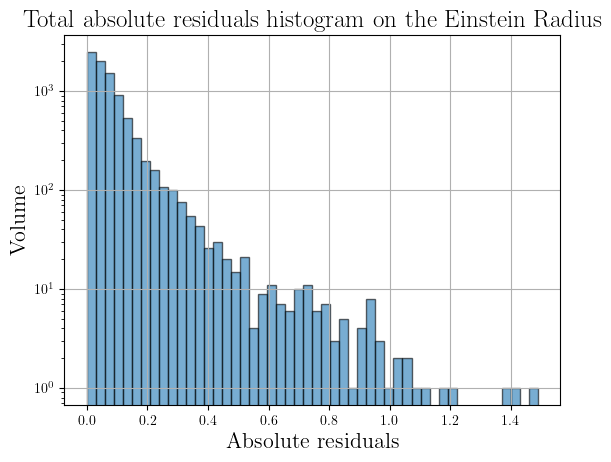

In [46]:
plt.hist(abs(y_true_denorm[:, 0] - y_pred_denorm[:, 0]), log = True, bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Total absolute residuals histogram on the Einstein Radius', fontsize = 18)
plt.xlabel('Absolute residuals', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()